# Quadratic Interpolation for $\alpha$, Conjugate Gradient and BFGS

> 📖 Book: [ch04](../../.claude/skills/ml-knowledge/chapters/ch04-linear-regression-gradient-descent.md) · Prev: [04](04_gd_exact_line_search.ipynb) · Next: [06 Multivariate regression](06_multivariate_and_feature_scaling.ipynb)

## Quadratic interpolation

Pick three values $\alpha_1 < \alpha_2 < \alpha_3$, hopefully close to the minimizer of $\varphi(\alpha) = J[\theta_k - \alpha\nabla J(\theta_k)]$. Build the quadratic polynomial $P(\alpha)$ that interpolates $\varphi$ at those three points; its minimum is trivial to find. Let $\hat\alpha \in [\alpha_1, \alpha_3]$ minimize $P$ and use it for the next iterate.

To save work:

1. $\alpha_1 = 0$.
2. Find $\alpha_3$ with $\varphi(\alpha_3) < \varphi(\alpha_1)$ by halving from $\alpha_3 = 1$ (it exists because $\alpha_1$ doesn't minimize $\varphi$).
3. $\alpha_2 = \alpha_3/2$.

The minimum of $P$ on $[\alpha_1, \alpha_3]$ is either at its unique critical point or at $\alpha_3$ (since $P(\alpha_3) = \varphi(\alpha_3) < \varphi(\alpha_1) = P(\alpha_1)$). With Newton's forward divided differences

$$
h_1 = \frac{\varphi(\alpha_2) - \varphi(\alpha_1)}{\alpha_2}, \quad
h_2 = \frac{\varphi(\alpha_3) - \varphi(\alpha_2)}{\alpha_3 - \alpha_2}, \quad
h_3 = \frac{h_2 - h_1}{\alpha_3},
$$

$$
P(\alpha) = \varphi(0) + h_1\alpha + h_3\,\alpha(\alpha - \alpha_2)
\quad\Longrightarrow\quad
\alpha_0 = \frac12\left(\alpha_2 - \frac{h_1}{h_3}\right),
$$

and we keep whichever of $\alpha_0, \alpha_3$ gives the smaller $J$. Unlike the exact line search, this works for **any** differentiable cost. In code: `gradient_descent(..., step="quadratic")`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sym
from scipy.optimize import minimize

from ml.optimization import conjugate_gradient, gradient_descent, quadratic
from ml.visualization.plots import plot_convergence, plot_cost_surface

plt.style.use("seaborn-v0_8-whitegrid")

### Visualizing one step

$\varphi(\alpha)$ along the first search direction from $\theta = (1, 1)^T$, the three samples, and the interpolating parabola:

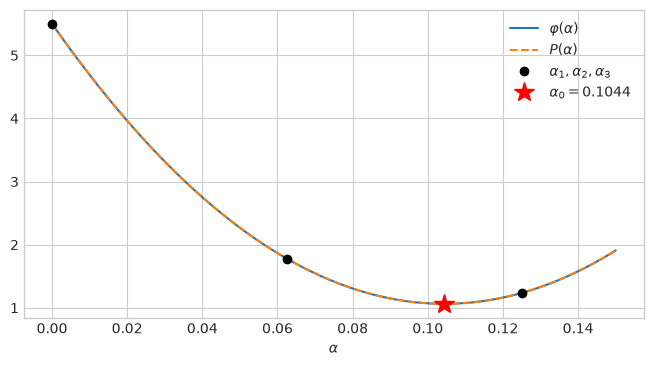

In [2]:
A = np.array([[10.0, 0.0], [0.0, 1.0]])
b = np.array([1.0, -1.0])
cost_q, grad_q = quadratic(A, b)
theta = np.array([1.0, 1.0])
g = grad_q(theta)
phi = np.vectorize(lambda a: cost_q(theta - a * g))

a3 = 1.0
while phi(a3) >= phi(0.0):
    a3 /= 2
a2 = a3 / 2
h1 = (phi(a2) - phi(0)) / a2
h2 = (phi(a3) - phi(a2)) / (a3 - a2)
h3 = (h2 - h1) / a3
a0 = 0.5 * (a2 - h1 / h3)

al = np.linspace(0, 1.2 * a3, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(al, phi(al), label=r"$\varphi(\alpha)$")
ax.plot(al, phi(0) + h1 * al + h3 * al * (al - a2), "--", label=r"$P(\alpha)$")
ax.plot([0, a2, a3], phi([0, a2, a3]), "ko", label=r"$\alpha_1, \alpha_2, \alpha_3$")
ax.plot(a0, phi(a0), "r*", ms=15, label=rf"$\alpha_0 = {a0:.4f}$")
ax.set(xlabel=r"$\alpha$")
ax.legend()
plt.show()

### Example 1: the paraboloid, with a symbolic gradient

We let [SymPy](https://www.sympy.org) differentiate $J(\theta_0, \theta_1) = 5\theta_0^2 + \frac12\theta_1^2 - \theta_0 + \theta_1$ and turn the expressions into NumPy functions.

In [3]:
t0, t1 = sym.symbols("theta_0 theta_1")
var = [t0, t1]


def symbolic(expr):
    """Cost and gradient (taking a vector theta) from a SymPy expression."""
    grad_expr = [sym.diff(expr, v) for v in var]
    f, df = sym.lambdify([var], expr, "numpy"), sym.lambdify([var], grad_expr, "numpy")
    return (lambda t: float(f(t))), (lambda t: np.array(df(t), dtype=float)), sym.Matrix(grad_expr)


cost, grad, grad_expr = symbolic(5 * t0**2 + sym.Rational(1, 2) * t1**2 - t0 + t1)
grad_expr

Matrix([
[10*theta_0 - 1],
[   theta_1 + 1]])

     theta0    theta1  J(theta)
0  1.000000  1.000000  5.500000
1  0.060197  0.791155  1.062039
2  0.339808 -0.467094 -0.120468
3  0.089394 -0.522742 -0.435550
4  0.163897 -0.858006 -0.519504
5  0.097174 -0.872833 -0.541874
6  0.117026 -0.962165 -0.547835
7  0.099247 -0.966116 -0.549423
8  0.104537 -0.989919 -0.549846
9  0.099799 -0.990972 -0.549959


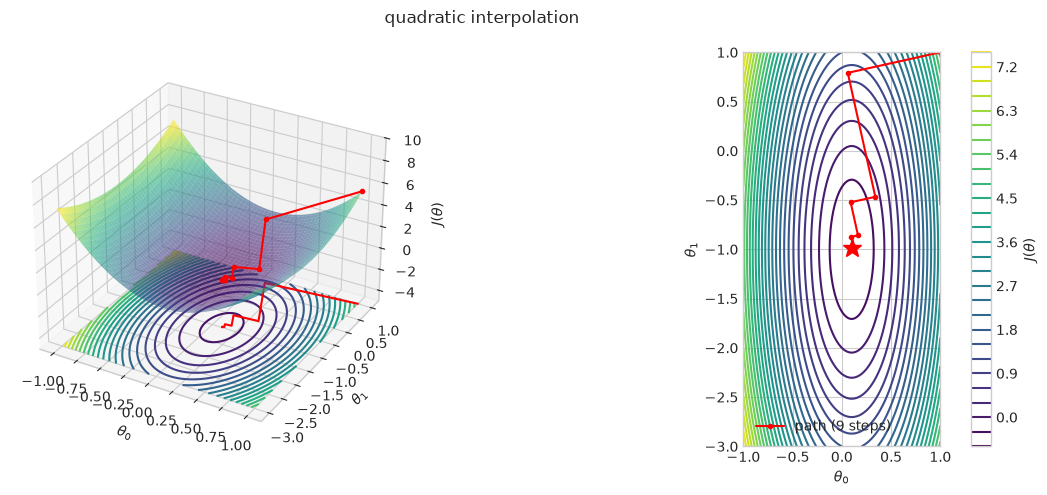

In [4]:
theta, hist_q = gradient_descent(cost, grad, np.array([1.0, 1.0]), step="quadratic", tol=0.01)
print(pd.DataFrame(hist_q, columns=["theta0", "theta1", "J(theta)"]))
plot_cost_surface(cost, hist_q, zlim=(-5, 10), title="quadratic interpolation")
plt.show()

On a quadratic, the interpolating parabola *is* $\varphi$, so this reproduces the exact line search – but without knowing $A$. It also applies to generic costs:

### Example 2: a non-convex cost

$$
J(\theta_0, \theta_1) = \cos(\theta_0 + \theta_1) + \sin\theta_0 + \cos\theta_1
$$

Matrix([
[-sin(theta_0 + theta_1) + cos(theta_0)],
[-sin(theta_1) - sin(theta_0 + theta_1)]])

from (1, -1) -> [-1.044 -2.622 -2.598]   from (-1, 2.5) -> [-1.046  3.664 -2.598]


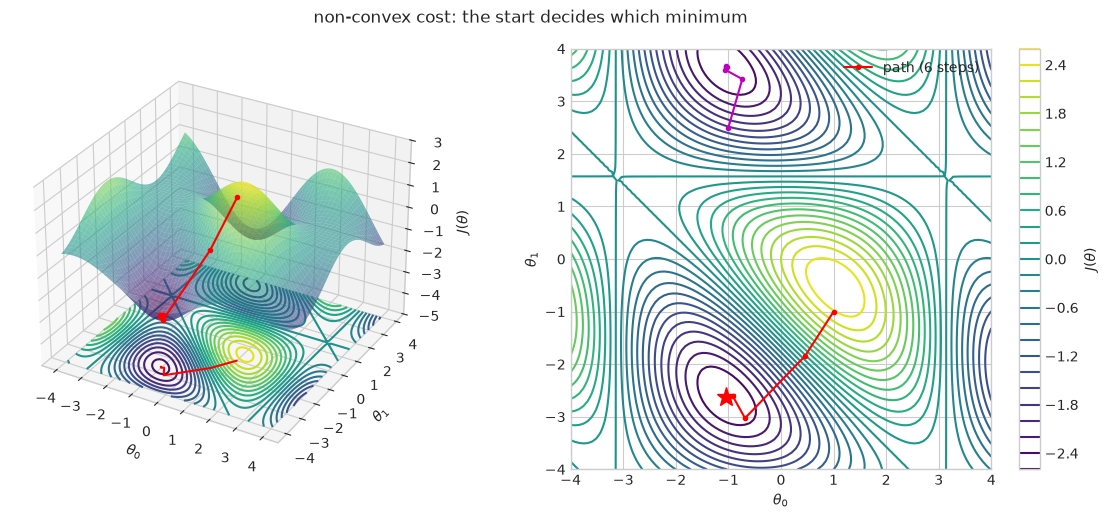

In [5]:
cost2, grad2, grad_expr2 = symbolic(sym.cos(t0 + t1) + sym.sin(t0) + sym.cos(t1))
display(grad_expr2)
_, hist2 = gradient_descent(cost2, grad2, np.array([1.0, -1.0]), step="quadratic", tol=0.01)
_, hist2b = gradient_descent(cost2, grad2, np.array([-1.0, 2.5]), step="quadratic", tol=0.01)
print("from (1, -1) ->", hist2[-1].round(3), "  from (-1, 2.5) ->", hist2b[-1].round(3))
fig = plot_cost_surface(cost2, hist2, t0=(-4, 4), t1=(-4, 4), zlim=(-5, 3), title="non-convex cost: the start decides which minimum")
ax = fig.axes[1]
ax.plot(hist2b[:, 0], hist2b[:, 1], "m.-")
plt.show()

Different starting points land in different local minima: on non-convex surfaces gradient methods only guarantee a *local* minimum.

## More sophisticated methods

- [Conjugate gradient](https://en.wikipedia.org/wiki/Conjugate_gradient_method) (CG)
- [Nonlinear conjugate gradient](https://en.wikipedia.org/wiki/Nonlinear_conjugate_gradient_method)
- [BFGS](https://en.wikipedia.org/wiki/Broyden%E2%80%93Fletcher%E2%80%93Goldfarb%E2%80%93Shanno_algorithm) and [L-BFGS](https://en.wikipedia.org/wiki/Limited-memory_BFGS) (quasi-Newton: build an approximation of the Hessian from gradients)
- [Nelder–Mead](https://en.wikipedia.org/wiki/Nelder%E2%80%93Mead_method) (derivative free)

They are faster than gradient descent and need no manual $\alpha$. Unless you are an expert in numerical computing, use tested libraries such as [`scipy.optimize`](https://docs.scipy.org/doc/scipy/reference/optimize.html): you only provide $J(\theta)$ and, ideally, $\nabla J(\theta)$.

### Conjugate gradient

Instead of following $-\nabla J$, CG moves along directions $p_k$ that are **$A$-conjugate** ($p_i^TAp_j = 0$ for $i \ne j$). Each step minimizes $J$ along $p_k$ without spoiling the previous directions, so on an $n$-dimensional quadratic it finishes in at most $n$ steps: no zig-zag.

$$
\alpha_k = \frac{r_k^Tr_k}{p_k^TAp_k}, \quad
x_{k+1} = x_k + \alpha_kp_k, \quad
r_{k+1} = r_k - \alpha_kAp_k, \quad
p_{k+1} = r_{k+1} + \frac{r_{k+1}^Tr_{k+1}}{r_k^Tr_k}p_k .
$$

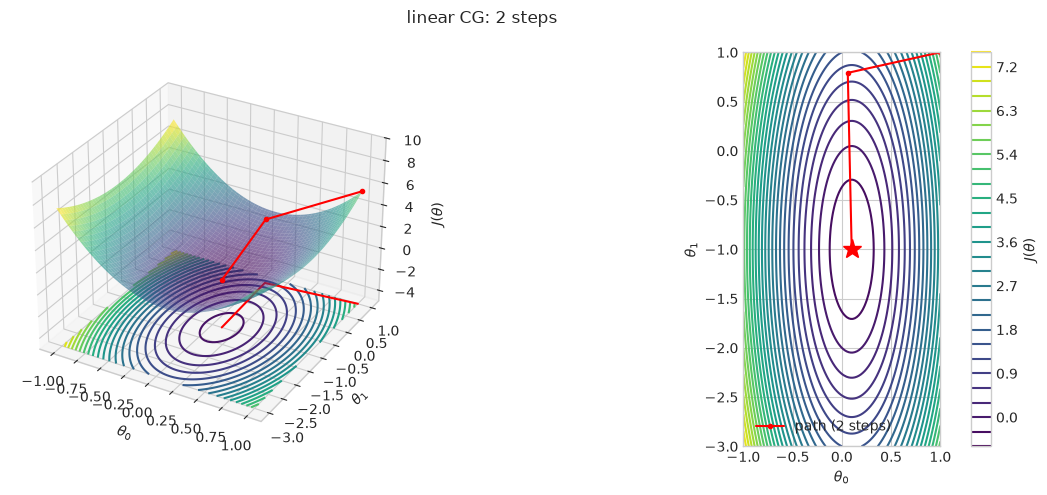

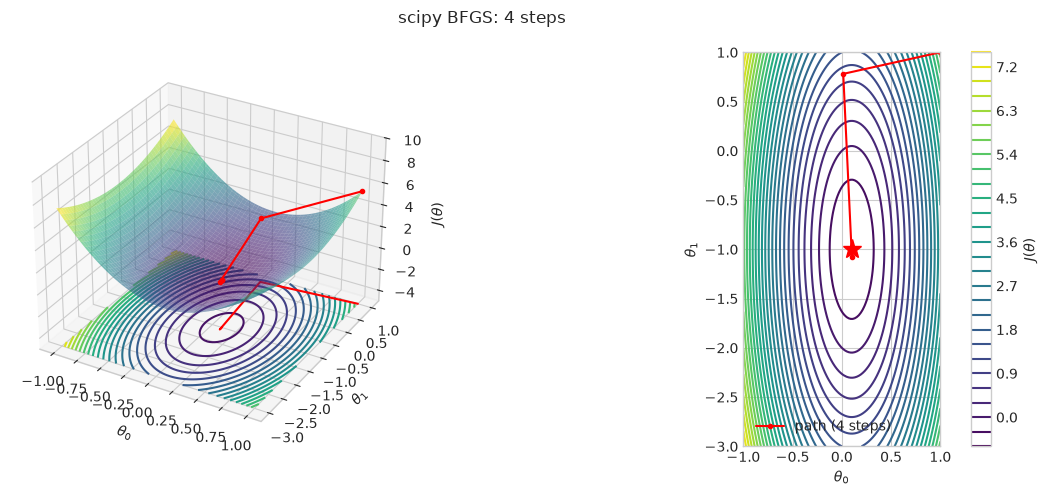

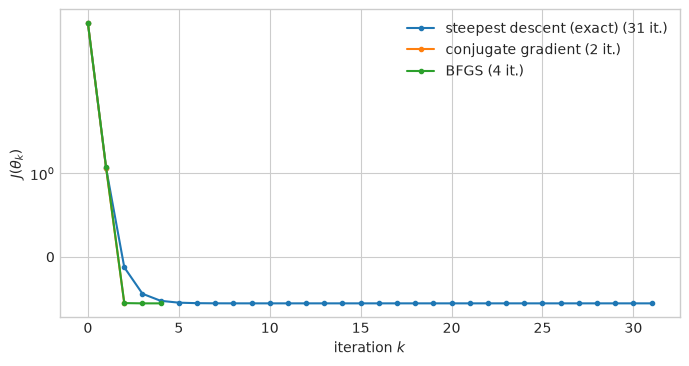

In [6]:
_, path_cg = conjugate_gradient(A, b, x0=np.array([1.0, 1.0]))
hist_cg = np.column_stack([path_cg, [cost_q(p) for p in path_cg]])


def scipy_path(method):
    rec = [np.array([1.0, 1.0])]
    minimize(cost_q, rec[0], jac=grad_q, method=method, tol=1e-8, callback=lambda xk: rec.append(xk.copy()))
    return np.array([np.append(r, cost_q(r)) for r in rec])


hist_bfgs = scipy_path("BFGS")
_, hist_exact = gradient_descent(cost_q, grad_q, np.array([1.0, 1.0]), step="exact", A=A, tol=1e-8)

fig = plot_cost_surface(cost_q, hist_cg, zlim=(-5, 10), title=f"linear CG: {len(hist_cg) - 1} steps")
plt.show()
fig = plot_cost_surface(cost_q, hist_bfgs, zlim=(-5, 10), title=f"scipy BFGS: {len(hist_bfgs) - 1} steps")
plt.show()
plot_convergence({"steepest descent (exact)": hist_exact, "conjugate gradient": hist_cg, "BFGS": hist_bfgs})
plt.show()

**Takeaways**

| Method | Needs | Cost per step | Convergence on a quadratic |
|---|---|---|---|
| GD, fixed $\alpha$ | $\nabla J$, tuned $\alpha$ | 1 gradient | linear, $\alpha < 2/\lambda_{max}$ |
| GD, exact / interpolated $\alpha$ | $\nabla J$ (+ extra $J$ evaluations) | 1 gradient + line search | linear, rate $\frac{\kappa-1}{\kappa+1}$ |
| Conjugate gradient | $\nabla J$ | 1 gradient | $\le n$ steps |
| BFGS | $\nabla J$ | $O(n^2)$ memory | superlinear |